## Forecasting Short-Term Shell Congestion Using Regression

This notebook estimates **short-term congestion trends** in each orbital shell (KMeans cluster).  
It uses only the information inside the **current dataset snapshot**.

### How it works
- Satellites are assigned to shells using **KMeans (CLUSTER)**.
- Each satellite has an **EPOCH date**, which tells when its orbital data was last updated.
- We group satellites by **CLUSTER + EPOCH (day)** to get:
  
  **“How many satellites were updated in this shell on this date?”**

- Using these counts, we fit a simple regression line to understand the **trend**:
  - Rising → congestion increasing  
  - Stable → congestion steady  
  - Falling → congestion reducing  

### Important Note
The regression **does not predict exact future satellite counts**.  
It only shows the **trend direction** inside the current dataset, which helps us judge if an orbital shell is:

- **Safe**
- **Moderate Risk**
- **High Risk**

for a new satellite launch based on **today’s congestion and trend**.

This makes the forecasting realistic, lightweight, and reliable without needing long-term historical data.


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline

#### Import necessary datasets

In [40]:
df = pd.read_csv('../data/06_streamlit_ready/anomaly_clustered.csv')

In [41]:
df.head(1)

,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,...,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,CALSPHERE 1,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,900,4390,...,7354.966693,983.966693,957.272299,996.661088,7.361703,61.912,C,0,-1,-0.015037


---
### Extract necessary features for forecasting

In [42]:
df = df[['EPOCH', 'NORAD_CAT_ID', 'CLUSTER']] 

In [43]:
df.shape

(12696, 3)

In [44]:
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3      38
0    1441
1    2088
4    4349
2    4780
Name: count, dtype: int64

---
### Prepare time column
- Convert epoch to DateTime object
- Extract the day (not time)

In [45]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12696 entries, 0 to 12695
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   EPOCH         12696 non-null  datetime64[ns]
 1   NORAD_CAT_ID  12696 non-null  int64         
 2   CLUSTER       12696 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 297.7 KB


In [47]:
df['EPOCH'] = df['EPOCH'].dt.floor('D')

In [48]:
merged_df.head()

,EPOCH,NORAD_CAT_ID,CLUSTER
0,2025-11-29,900,0
1,2025-11-29,902,0
2,2025-11-29,1512,0
3,2025-11-29,1520,0
4,2025-11-29,2826,0


In [49]:
# Create simple time series dataset
shell_time_series = df.groupby(['EPOCH', 'CLUSTER']).size().reset_index(name='SATELLITE_COUNT')

In [50]:
shell_time_series.head()

,EPOCH,CLUSTER,SATELLITE_COUNT
0,2025-11-08,4,1
1,2025-11-12,1,1
2,2025-11-18,1,2
3,2025-11-20,1,1
4,2025-11-20,3,1


---
### Save in a CSV file

In [51]:
shell_time_series.to_csv('../data/06_streamlit_ready/shell_time_series.csv')

### Apply regression on the created time series dataset :

### Meaning of Activity Fraction

`ACTIVITY_FRACTION` represents how active a shell is based on how many of its satellites were recently updated.

It is calculated as:

**activity_fraction = (satellites updated on this date) / (total updates in this shell)**

Values are between 0 and 1:

- **Closer to 1** → high recent activity (busy or unstable shell)  
- **Closer to 0** → low recent activity (stable shell)

Regression is applied to this fraction to understand whether the shell’s activity is rising, stable, or falling.


In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
cluster_models = [] # Store cluster specific model information
activity_df = pd.DataFrame() # Store cluster data with fraction for each day

for cluster in range(shell_time_series['CLUSTER'].nunique()):
    # Filter rows for the current cluster
    cluster_rows = shell_time_series[shell_time_series['CLUSTER'] == cluster].copy()
    
    # Skip clusters that have fewer than 2 data points
    if len(cluster_rows) < 2:
        print(f"Cannot regress cluster {cluster}")
        continue

    # Convert EPOCH into numeric days starting from the earliest date
    cluster_rows['EPOCH_NUM'] = (
        (cluster_rows["EPOCH"] - cluster_rows["EPOCH"].min()).dt.total_seconds() / (24 * 3600)
    )

    # Compute activity fraction for regression target
    total_updates = cluster_rows['SATELLITE_COUNT'].sum()
    cluster_rows['ACTIVITY_FRACTION'] = cluster_rows['SATELLITE_COUNT'] / total_updates

    
    # Set up regression inputs
    X = cluster_rows[['EPOCH_NUM']]
    y = cluster_rows[['ACTIVITY_FRACTION']]

    # Fit the regression model
    model = LinearRegression()
    model.fit(X, y)

    # Extract slope, intercept, and latest activity fraction
    slope = round(model.coef_[0][0], 5)
    intercept = round(model.intercept_[0], 5)
    current_fraction = round(y.iloc[-1].values[0], 5)

    # Store model details
    cluster_models.append({
        'Cluster': cluster,
        'Model': model,
        'Slope': slope,
        'Intercept': intercept,
        'Current activity fraction': current_fraction
    })

    # Add the cluster rows to the activity_df
    cluster_map = {}
    activity_df = pd.concat([activity_df, cluster_rows])


# Reset activity_df index
activity_df = activity_df.reset_index(drop=True)

In [54]:
activity_df

,EPOCH,CLUSTER,SATELLITE_COUNT,EPOCH_NUM,ACTIVITY_FRACTION
0,2025-11-25,0,1,0.0,0.000694
1,2025-11-27,0,7,2.0,0.004858
2,2025-11-28,0,175,3.0,0.121443
3,2025-11-29,0,1258,4.0,0.873005
4,2025-11-12,1,1,0.0,0.000479
5,2025-11-18,1,2,6.0,0.000958
6,2025-11-20,1,1,8.0,0.000479
7,2025-11-21,1,2,9.0,0.000958
8,2025-11-23,1,2,11.0,0.000958
9,2025-11-24,1,1,12.0,0.000479


In [55]:
cluster_models

[{'Cluster': 0,
  'Model': LinearRegression(),
  'Slope': np.float64(0.18469),
  'Intercept': np.float64(-0.16556),
  'Current activity fraction': np.float64(0.873)},
 {'Cluster': 1,
  'Model': LinearRegression(),
  'Slope': np.float64(0.02291),
  'Intercept': np.float64(-0.1611),
  'Current activity fraction': np.float64(0.7931)},
 {'Cluster': 2,
  'Model': LinearRegression(),
  'Slope': np.float64(0.25841),
  'Intercept': np.float64(-0.13762),
  'Current activity fraction': np.float64(0.79895)},
 {'Cluster': 3,
  'Model': LinearRegression(),
  'Slope': np.float64(0.06248),
  'Intercept': np.float64(-0.07804),
  'Current activity fraction': np.float64(0.73684)},
 {'Cluster': 4,
  'Model': LinearRegression(),
  'Slope': np.float64(0.01602),
  'Intercept': np.float64(-0.10656),
  'Current activity fraction': np.float64(0.54495)}]

---
### Visualizing the model O/P

#### Activity Fraction vs Time (Per Cluster) + Regression trend line

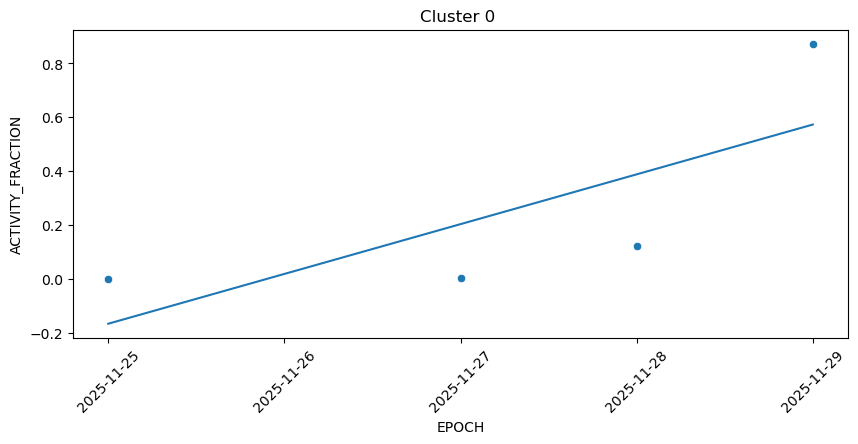

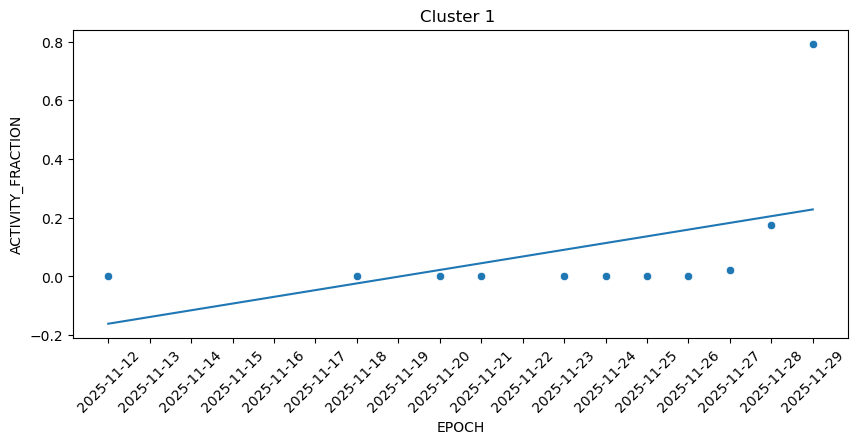

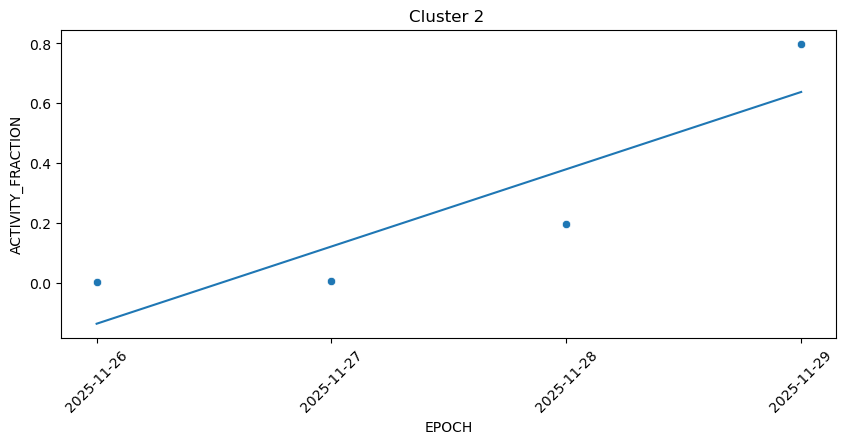

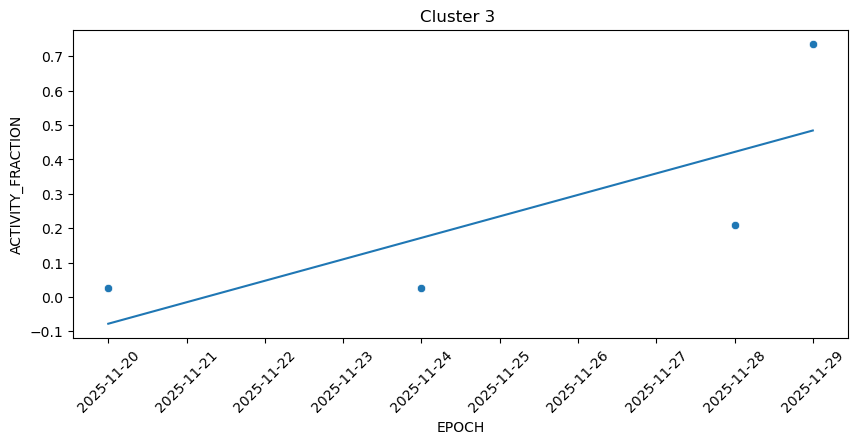

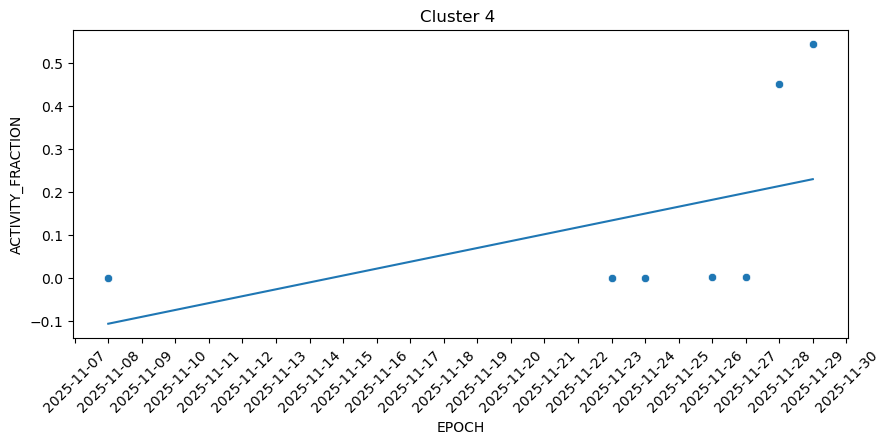

In [56]:
import matplotlib.dates as mdates

for cluster in range(activity_df['CLUSTER'].nunique()):

    plt.figure(figsize=(10, 4))
    plt.title(F'Cluster {cluster} ')
    cluster_rows = activity_df[activity_df['CLUSTER'] == cluster].copy()
    
    # Plot raw data points
    sns.scatterplot(data=cluster_rows, x = 'EPOCH', y = 'ACTIVITY_FRACTION')

    # Obtain perticular model for this cluster and plot the regression line
    model = cluster_models[cluster]['Model']

    y_pred = model.predict(cluster_rows[['EPOCH_NUM']])
    plt.plot(cluster_rows['EPOCH'], y_pred)

    # Resolve the date tick label issue
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())

    
    plt.xticks(rotation=45)

#### Cluster Comparison

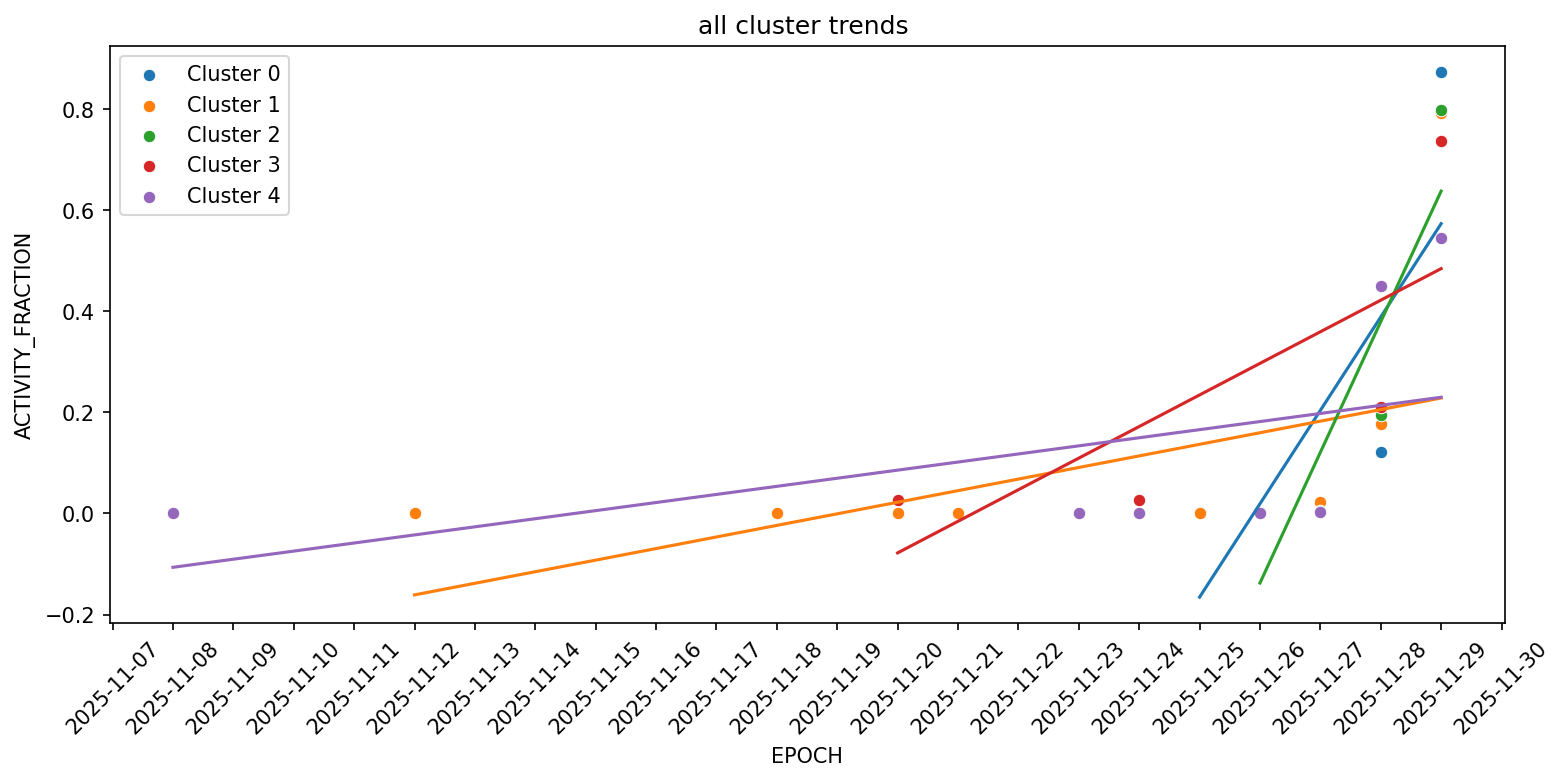

In [57]:

plt.figure(figsize=(12, 5), dpi=150)
for cluster in range(activity_df['CLUSTER'].nunique()):

    plt.title(F'all cluster trends ')
    cluster_rows = activity_df[activity_df['CLUSTER'] == cluster].copy()
    
    # Plot raw data points
    sns.scatterplot(data=cluster_rows, x = 'EPOCH', y = 'ACTIVITY_FRACTION', label=f'Cluster {cluster}')

    # Obtain perticular model for this cluster and plot the regression line
    model = cluster_models[cluster]['Model']

    y_pred = model.predict(cluster_rows[['EPOCH_NUM']])
    plt.plot(cluster_rows['EPOCH'], y_pred)

    # Resolve the date tick label issue
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    
    plt.legend()
    plt.xticks(rotation=45)

#### Final Trend Summary

In [58]:
trend_summary = pd.DataFrame(columns=['CLUSTER_ID', 'SLOPE', 'CURRENT_ACTIVITY_FRACTION', 'TREND_TYPE', 'LAUNCH_RISK_LEVEL'])

"""
Define trend type based on 'relative' slope in each cluster : 
    
    normalized = slope / max_slope (bewteen  0 to 1)
    
    > 0.70     → Strong Rising
    0.30–0.70  → Moderate Rising
    0.10–0.30  → Mild Rising
    -0.10–0.10 → Flat
    < -0.10    → Calming
 """


"""
Launch Risk Level (Final Rule Table — Clean & Correct)

Risk Level      | Trend Condition (normalized slope)          | Current Activity Fraction
-------------------------------------------------------------------------------------------------------
High            | Strong Rising or Moderate Rising (>= 0.30)  | > 0.30

Moderate        | Mild Rising (0.00 – 0.29) 
                | OR any near-flat trend with notable activity | 0.10 – 0.35

Low             | Flat / Stable or Calming                    | < 0.10
"""


min_slope = min(d['Slope'] for d in cluster_models)
max_slope = max(d['Slope'] for d in cluster_models)
 
# Use the clustered_model to add the cluster related information obtained through regression
for item in cluster_models:
    cluster = item['Cluster']
    slope = item['Slope']
    current_fraction = item['Current activity fraction']

    # 1. Relative slope strength/trend
    # Scale the relative strength betwwen 0 to 1
    normalized = (slope - min_slope) / (max_slope - min_slope) 

    # Trend classification
    if normalized > 0.70:
        trend_type = 'Strong Rising'
    elif normalized >= 0.30:
        trend_type = 'Moderate Rising'
    elif normalized >= 0.10:
        trend_type = 'Mild Rising'
    elif normalized >= -0.10:
        trend_type = 'Flat'
    else:
        trend_type = 'Calming'


    # 2. Launch risk score classification
    if (normalized >0.3) and (current_fraction >0.3): # Strong & Moderate rising
        risk_level = 'High'
    elif (0.29>=normalized>=0.0) and (0.35>=current_fraction>=0.0): # Mild rising / any rising trend
        risk_level = 'Moderate'
    else: # Flat / Stable / Calming
        risk_level = 'Low'
        

    # Append row data
    trend_summary.loc[len(trend_summary)] = [cluster, slope, current_fraction, trend_type, risk_level]
    
    

In [59]:
trend_summary

,CLUSTER_ID,SLOPE,CURRENT_ACTIVITY_FRACTION,TREND_TYPE,LAUNCH_RISK_LEVEL
0,0,0.18469,0.87300,Moderate Rising,High
1,1,0.02291,0.79310,Flat,Low
2,2,0.25841,0.79895,Strong Rising,High
3,3,0.06248,0.73684,Mild Rising,Low
4,4,0.01602,0.54495,Flat,Low


In [60]:
cluster_models

[{'Cluster': 0,
  'Model': LinearRegression(),
  'Slope': np.float64(0.18469),
  'Intercept': np.float64(-0.16556),
  'Current activity fraction': np.float64(0.873)},
 {'Cluster': 1,
  'Model': LinearRegression(),
  'Slope': np.float64(0.02291),
  'Intercept': np.float64(-0.1611),
  'Current activity fraction': np.float64(0.7931)},
 {'Cluster': 2,
  'Model': LinearRegression(),
  'Slope': np.float64(0.25841),
  'Intercept': np.float64(-0.13762),
  'Current activity fraction': np.float64(0.79895)},
 {'Cluster': 3,
  'Model': LinearRegression(),
  'Slope': np.float64(0.06248),
  'Intercept': np.float64(-0.07804),
  'Current activity fraction': np.float64(0.73684)},
 {'Cluster': 4,
  'Model': LinearRegression(),
  'Slope': np.float64(0.01602),
  'Intercept': np.float64(-0.10656),
  'Current activity fraction': np.float64(0.54495)}]